## Making trees work - Exercise
```In this exercise you will experience with Decision Trees and Random Forests. During this part you will explore the different features of them and will plot your results. Hence, whenever exploration tasks are marked with (*), know that you are asked to plot two graphs (on the same plot): the training score against the explored feature and the test score against it.```

```~Ittai Haran```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

```Read the dataset. In this dataset, you are provided over a hundred variables describing attributes of life insurance applicants. The task is to predict the "Response" variable.```

```the dataset can be found in: ```https://drive.google.com/open?id=1t_P64gM1M1_c2n4PvH7AZoELH2CNh6ui

In [3]:
from sklearn.model_selection import train_test_split
df = pd.read_csv('c:/Users/user/Desktop/DStrainig/intro/supervised/insurance_fixed.csv')
X = df.drop(['Response'], axis = 1)
Y = df['Response']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size = 0.7, test_size = 0.3)

```We will start by using Decision trees. Use a simple DecisionTreeClassifier with default values to predict on your train and on your test. Evaluate the model using the accuracy metric, which you can find in sklearn.```

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


In [33]:
DecisionTree = DecisionTreeClassifier()
DecisionTree.fit(X_train, Y_train)
print(accuracy_score(Y_train, DecisionTree.predict(X_train)))
print(accuracy_score(Y_test, DecisionTree.predict(X_test)))


1.0
0.41987089531293853


```Unfortunately, you are at overfit. Now let's try to get better. Try playing with the max depth of the tree, for``` $1\leq depth \leq25$ ```(*) (This means you are asked to plot some graphs, remember? :) )```

```Choose the optimal max_depth based on the graph you got.```

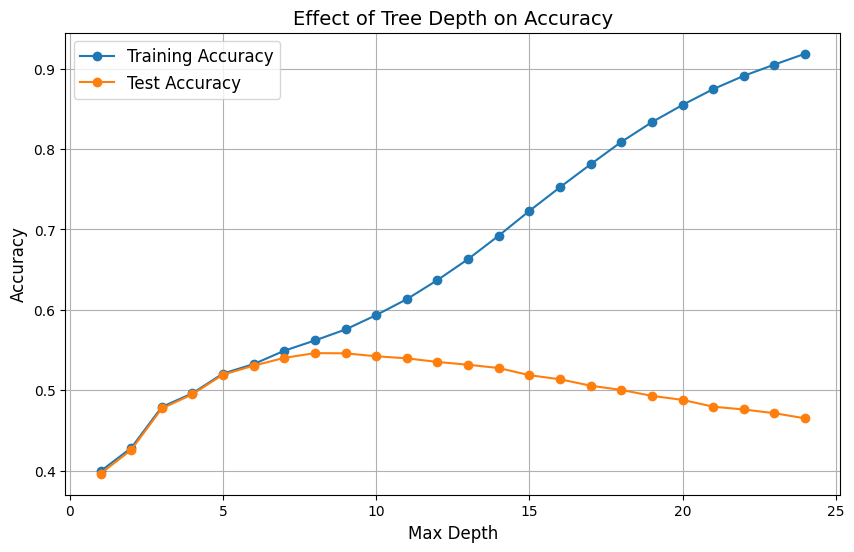

In [34]:

depth_values = range(1, 25)

train_scores = []
test_scores = []

for depth in depth_values:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, Y_train)
    
    train_accuracy = accuracy_score(Y_train, tree.predict(X_train))
    test_accuracy = accuracy_score(Y_test, tree.predict(X_test)) 
    train_scores.append(train_accuracy)
    test_scores.append(test_accuracy)

plt.figure(figsize=(10, 6))
plt.plot(depth_values, train_scores, label="Training Accuracy", marker='o')
plt.plot(depth_values, test_scores, label="Test Accuracy", marker='o')
plt.xlabel("Max Depth", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Effect of Tree Depth on Accuracy", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()


```Choose the best max_depth you found. Now try playing with min_samples_leaf. use the following values: [1, 10, 100, 300,700, 1000]. Do it also with max_depth = 20. What can we learn from the graphs? Please answer the question``` $\ \underline{in\ another\ cell}$ ```.(*)```

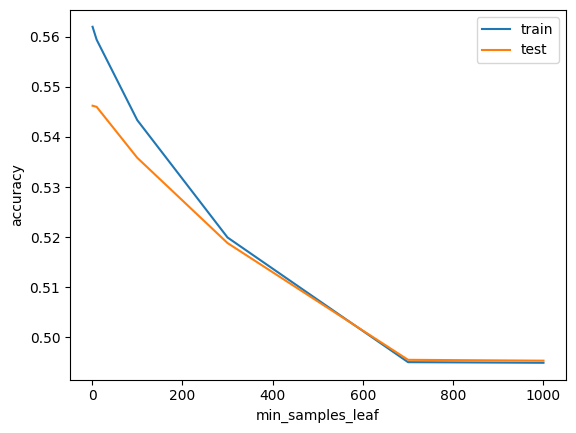

In [49]:

training_score = []
test_score = []
min_samples_leaves = [1, 10, 100, 300,700, 1000]
for min_samples_leaf in min_samples_leaves:
    basic_tree = DecisionTreeClassifier(max_depth=8, min_samples_leaf=min_samples_leaf,random_state=42)
    basic_tree.fit(X_train, Y_train)
    training_score.append(accuracy_score(Y_train, basic_tree.predict(X_train)))
    test_score.append(accuracy_score(Y_test, basic_tree.predict(X_test)))
plt.plot(min_samples_leaves, training_score,label="train")
plt.plot(min_samples_leaves, test_score,label="test")
plt.xlabel('min_samples_leaf')
plt.ylabel('accuracy')
plt.legend()
plt.show()

```Decision Tree is a very nice algorithm, especially because it is very intuitive and explainable. We can even draw it!
Train a simple Decision Tree with max_depth = 3. Call it basic_tree and run the cell below. Examine the file tree.png you created.```

In [53]:
basic_tree = DecisionTreeClassifier(max_depth=3)
basic_tree = basic_tree.fit(X_train, Y_train)

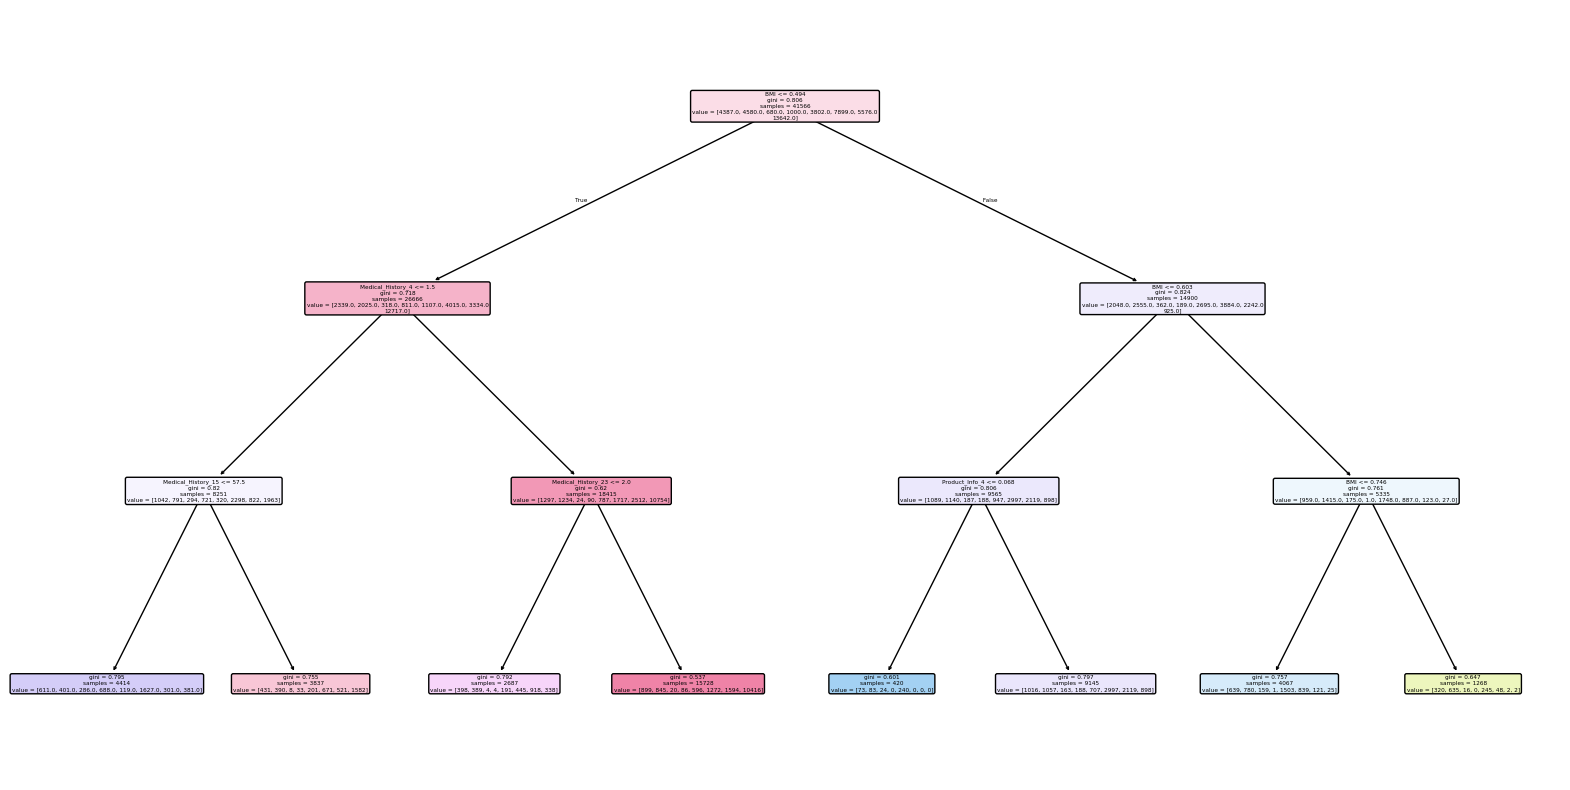

In [54]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(basic_tree, 
          feature_names=X.columns,
          filled=True, 
          rounded=True)
plt.show()

```Look at the tree you got. What, would you say, are the most important features?
As you recall, we talked about feature importance in the lecture notes. Use the attribute feature_importance_ of your tree to get a list of the most important features.```

In [67]:
basic_tree = DecisionTreeClassifier(max_depth=3)
basic_tree = basic_tree.fit(X_train, Y_train)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': basic_tree.feature_importances_
})

important_features = feature_importance[feature_importance['importance'] > 0].sort_values('importance', ascending=False)

print(important_features)

               feature  importance
9                  BMI    0.539180
39   Medical_History_4    0.188188
58  Medical_History_23    0.167714
50  Medical_History_15    0.071047
2       Product_Info_4    0.033871


```We will now move to Random Forest. Repeat the exlporations tasks with a Random forest with 100 trees (max depth and min samples leaf). In addition, vary the number of trees between 10 and 400, while maintaining low max_depth (*) and the max_feature parameter, between 0.1 and 1 (*). Try explaining the graphs you see ```$\ \underline{in\ a\ different\ cell}$```. Use the flag n_jobs = -1 in your experiments to accelerate your computation time. Make sure to understand where your model is overfitted.```

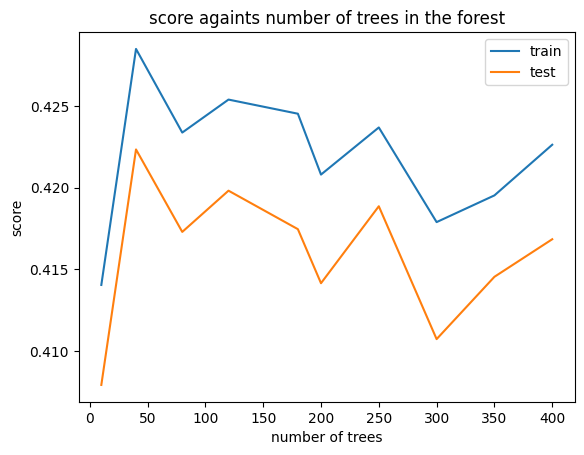

In [ ]:
from sklearn.ensemble import RandomForestClassifier

training_score = []
test_score = []
number_of_trees = [10,40,80,120,180,200,250,300,350,400]
for number in number_of_trees:
    random_forest = RandomForestClassifier(n_estimators=number, max_depth=8)
    random_forest.fit(X_train, Y_train)
    training_score.append(accuracy_score(Y_train, random_forest.predict(X_train)))
    test_score.append(accuracy_score(Y_test, random_forest.predict(X_test)))
plt.plot(number_of_trees, training_score,label="train")
plt.plot(number_of_trees, test_score,label="test")
plt.xlabel('number of trees')
plt.ylabel('score')
plt.legend()
plt.title('score againts number of trees in the forest')
plt.show()

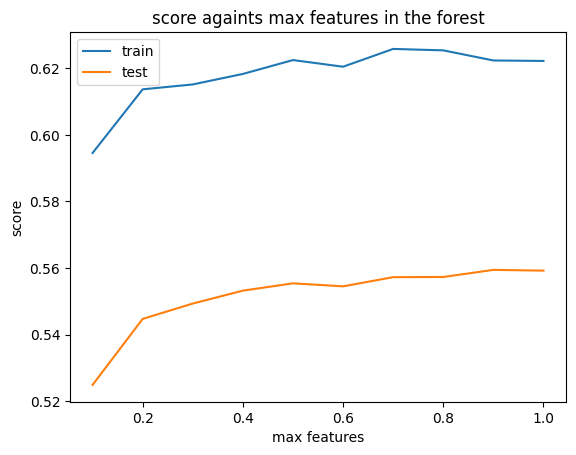

In [71]:
training_score = []
test_score = []
max_features_list = np.arange(0.1,1.1,0.1)
for max_features in max_features_list:
    random_forest = RandomForestClassifier(n_estimators=100, max_depth=10, max_features=max_features, n_jobs = -1)
    random_forest.fit(X_train, Y_train)
    training_score.append(accuracy_score(Y_train, random_forest.predict(X_train)))
    test_score.append(accuracy_score(Y_test, random_forest.predict(X_test)))
plt.plot(max_features_list, training_score, label='train')
plt.plot(max_features_list, test_score, label='test')
plt.xlabel('max features')
plt.ylabel('score')
plt.legend()
plt.title('score againts max features in the forest')
plt.show()

```As you could see, at least one of your graphs turned out to be very noisy. Use K Fold cross validation to evalute your model more accurately. In K Fold cross validation we split our data into K segments, and for each ```$\ 1\leq i\leq K\ $``` we test our model on the i-th segment while training it using the others.```

In [72]:

from sklearn.model_selection import KFold

number_of_trees = [10, 40, 80, 120, 180, 200, 250, 300, 350, 400]
training_score = []
test_score = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for number in number_of_trees:
    fold_train_scores = []
    fold_test_scores = []
    
    for train_index, test_index in kf.split(X_train):
        X_train_fold, X_test_fold = X_train.iloc[train_index], X_train.iloc[test_index]
        Y_train_fold, Y_test_fold = Y_train.iloc[train_index], Y_train.iloc[test_index]

        random_forest = RandomForestClassifier(n_estimators=number, max_depth=4)
        random_forest.fit(X_train_fold, Y_train_fold)
        fold_train_scores.append(accuracy_score(Y_train_fold, random_forest.predict(X_train_fold)))
        fold_test_scores.append(accuracy_score(Y_test_fold, random_forest.predict(X_test_fold)))
    
    training_score.append(np.mean(fold_train_scores))
    test_score.append(np.mean(fold_test_scores))

plt.plot(number_of_trees, training_score, label="train")
plt.plot(number_of_trees, test_score, label="test")
plt.xlabel('Number of trees')
plt.ylabel('Score')
plt.legend()
plt.title('Score against number of trees in the forest with K-Fold Cross-Validation')
plt.show()


```Use the Random Forest to surpass the best score you got using Decision Tree.```

In [70]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [1, 2, 4, 6]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    n_jobs=-1,
    scoring='accuracy',
    verbose=2
)

grid_search.fit(X_train, Y_train)

print("\nBest parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200}
Best cross-validation score: 0.5193908807444458


In [84]:
rf = RandomForestClassifier(n_jobs=-1)

param_grid = {
    'n_estimators': [100, 200, 300], 
    'max_depth': [5, 10, 15],         
    'max_features': [ 0.7, 0.9],  
    'min_samples_leaf': [1, 2, 4]   
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

grid_search.fit(X_train, Y_train)

print(f"Best parameters found: {grid_search.best_params_}")

best_rf = grid_search.best_estimator_
print("Test accuracy with best parameters: ", accuracy_score(Y_test, best_rf.predict(X_test)))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters found: {'max_depth': 15, 'max_features': 0.7, 'min_samples_leaf': 2, 'n_estimators': 300}
Test accuracy with best parameters:  0.5628964355879876


In [82]:
rf = RandomForestClassifier(n_estimators=400, max_depth=10, max_features=0.9, n_jobs=-1)
rf.fit(X_train, Y_train)
print(accuracy_score(Y_test, rf.predict(X_test)))

0.5562166713443727


## Extra thinking on feature importance

```We talked about feature importance in the lecture notes. get the feature importance of each feature using a decision tree and using a random forest. Use in both cases the best hyper parameters you found so far. Discuss the differences between the answers``` $\underline{in\ a\ cell}$.

In [11]:
# DecisionTreeClassifier Feature Importance
basic_tree = DecisionTreeClassifier(max_depth=6)
basic_tree = basic_tree.fit(X_train, Y_train)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': basic_tree.feature_importances_
})
important_features = feature_importance[feature_importance['importance'] > 0].sort_values('importance', ascending=False)
print(important_features.head(10))  

# RandomForestClassifier Feature Importance
rf = RandomForestClassifier(n_estimators=200, max_depth=6, n_jobs=-1)
rf.fit(X_train, Y_train)
rf_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
})
rf_feature_importance = rf_feature_importance[rf_feature_importance['importance'] > 0].sort_values('importance', ascending=False)
print(rf_feature_importance.head(10))  
#IN RANDOM FOREST WITH CHOOSE RANDOMLY FEATURES... SO IN MANY TREES THERE IS NO 'BMI'

               feature  importance
9                  BMI    0.405640
39   Medical_History_4    0.148850
58  Medical_History_23    0.133903
2       Product_Info_4    0.102566
50  Medical_History_15    0.062483
79   Medical_Keyword_3    0.052839
6              Ins_Age    0.026496
65  Medical_History_30    0.016416
59  Medical_History_24    0.012515
91  Medical_Keyword_15    0.010143
               feature  importance
9                  BMI    0.192919
8                   Wt    0.153136
58  Medical_History_23    0.098156
39   Medical_History_4    0.085142
2       Product_Info_4    0.079940
91  Medical_Keyword_15    0.077808
79   Medical_Keyword_3    0.038128
21       InsuredInfo_6    0.028580
6              Ins_Age    0.028338
50  Medical_History_15    0.021158


```We can define a concept of feature importance for linear regression: Suppose you have two features, ```$x_1$ ```and``` $x_2$. ```Suppose that you got a linear regression of the form```

$y = 100\cdot x_1 + 1\cdot x_2$

```What feature is more important? What if we have -100 instead of 100? Generalize this idea to any number of features. Train a linear regression on your data and get the feature importances.```

In [ ]:
# BASED ON MAGNITUD X1 IS WAY MORE IMPORTATNT NO MATTER THR SIGN

## Feature selection
```We will now try using the feature_importance we can get from our models to do a wise feature selection.```

Do the following:



*   ```Take the best Random Forest model you got at the last part.```
*   ```Select the top 20 feature with the greatest feature importance.```
*   ```Train a KNN model with n_neighbors = 8 (and n_jobs = -1). What is its accuracy?```
*   ```Train a KNN model using the 20 features you found, again with n_neighbors = 8 (and n_jobs = -1). What is its accuracy? What can we learn from it?```
*   ```Repeat the two last tasks, this time with the best Random Forest configuration you found. Can you explain the results?```
*   ```Draw a graph where the y axis is a feature_importance sum, and the x axis is the number of features you must take to get this sum. How can this graph help you to explain your results?```

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

rf = RandomForestClassifier(n_estimators=300, max_depth=15, n_jobs=-1,max_features= 0.7)
rf.fit(X_train, Y_train)
rf_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
})

top_20_features = rf_feature_importance.sort_values('importance', ascending=False).head(20)

selected_features = top_20_features['feature'].tolist()

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

In [19]:
knn_all_f = KNeighborsClassifier(n_neighbors=8, n_jobs=-1)
knn_all_f.fit(X_train, Y_train)

Y_pred = knn_all_f.predict(X_test)
accuracy = accuracy_score(Y_test, Y_pred)
print("Accuracy of KNN model:", accuracy)

Accuracy of KNN model: 0.3306763962952568


In [20]:
knn_20_f = KNeighborsClassifier(n_neighbors=8, n_jobs=-1)
knn_20_f.fit(X_train_selected, Y_train)

Y_pred = knn_20_f.predict(X_test_selected)
accuracy = accuracy_score(Y_test, Y_pred)
print("Accuracy of KNN model:", accuracy)

Accuracy of KNN model: 0.34891944990176815


```We will now implement a primitive reduction of Seffi's feature selection method (you are encouraged to ask him about it):```
- ```Take the best Random Forest model you found.```
- ```Create a dictionary that holds {feature: its importance}.```
- ```Transpose the df matrix, so we may think on the columns as 'samples' and vice versa.```
- ```Normalize each 'sample', so its length is 1.```
- ```Use KMeans with n_clusters = 20 on the 'samples'.```
- ```From each cluster take the feature with the highest feature importance.```

## Ensemble methods and stacking
```In this part we will explore the concept of model stacking: that is, training a model, the combining model, on the outputs of several other models. Hence, the stacking method has two steps: first we train our models, and than we train the combining model using the outputs of those models.```

```In the setting of stacking models it is very important to train the several models on one segment of the data and train the combining model on another segment. Hence, start by splitting the data to 3 segments: train_1 segment, 35% of the data, train_2 segment, 35% of the data, and test segment, the last 30% of the data.```

In [21]:
df = pd.read_csv('c:/Users/user/Desktop/DStrainig/intro/supervised/insurance_fixed.csv')

X = df.drop(['Response'], axis=1)
Y = df['Response']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.7, test_size=0.3, random_state=42)

X_train_1, X_train_2, Y_train_1, Y_train_2 = train_test_split(X_train, Y_train, train_size=0.5, test_size=0.5, random_state=42)



train_1 size: 20783 rows
train_2 size: 20783 rows
test size: 17815 rows


```Our first experiment is as follows: train a random forest of simple decision trees (30 trees, max_depth = 3), using train_1. Use the estimators of the forest to create 30*8=240 features: for each estimator get the probabilities it gives for the target to belong to any of the classes. You can get the list of the estimators using RandomForestClassifier.estimators_ and have the probabilities mentioned using model.predict_proba.
Using the new features you got (and them only), train a logistic regression (LogisticRegression).
Compare between the accuracy of the first random forest (on the test segment) and the accuracy of the stacked models (again, on the test segment).```

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

C:\Users\user\Anaconda3\lib\importlib\_bootstrap.py:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 216 from PyObject
  return f(*args, **kwds)


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
import numpy as np

segments = [X_train_1.index, X_train_2.index]

model_1 = RandomForestClassifier(n_estimators=30, max_depth=3, max_features=0.8, n_jobs=-1)

X_train_1 = df.iloc[segments[0]].drop(['Response'], axis=1)
Y_train_1 = df.iloc[segments[0]]['Response']
model_1.fit(X_train_1, Y_train_1)

print('model accuracy on test set: ' + str(accuracy_score(Y_test, model_1.predict(X_test).astype(int))))
print('log loss on test set: ' + str(log_loss(Y_test, model_1.predict_proba(X_test))))

X_train_2 = df.iloc[segments[1]].drop(['Response'], axis=1)
Y_train_2 = df.iloc[segments[1]]['Response']

all_results = np.concatenate([x.predict_proba(X_train_2) for x in model_1.estimators_], axis=-1)

model = LogisticRegression()
model.fit(all_results, Y_train_2)

all_results_test = np.concatenate([x.predict_proba(X_test) for x in model_1.estimators_], axis=-1)
predictions = model.predict_proba(all_results_test)

print('stacked model accuracy on test set: ' + str(accuracy_score(Y_test, model.predict(all_results_test))))
print('log loss on test set: ' + str(log_loss(Y_test, predictions)))


model accuracy on test set: 0.4971653101319113
log loss on test set: 1.4689046050859325


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:486: UserWarning: X has feature name

stacked model accuracy on test set: 0.5198428290766208
log loss on test set: 1.3945231436423078


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


```We will conduct a similar experiment: create a set of at least 5 different models, of different kinds - use algorithms we talked about in the course. Stack them to get a better model. Compare the accuracies of the models to the accuracy of your stacked model.```

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression, LogisticRegressionCV, LogisticRegression, RidgeClassifier, RidgeClassifierCV

In [3]:
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split
import numpy as np

df = pd.read_csv('c:/Users/user/Desktop/DStrainig/intro/supervised/insurance_fixed.csv')

X = df.drop(['Response'], axis=1)
Y = df['Response']

X_train_1, X_temp, Y_train_1, Y_temp = train_test_split(X, Y, train_size=0.7, test_size=0.3, random_state=42)
X_train_2, X_test, Y_train_2, Y_test = train_test_split(X_temp, Y_temp, train_size=0.5, test_size=0.5, random_state=42)

model_svm = SVC(probability=True, kernel='rbf', random_state=42)
model_rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
model_logistic = LogisticRegression(random_state=42)

models = [model_svm, model_rf, model_logistic]

for model in models:
    model.fit(X_train_1, Y_train_1)
    print(f'{model.__class__.__name__} trained on train_1.')

all_results_train_2 = np.concatenate([model.predict_proba(X_train_2) for model in models], axis=-1)

stacking_model = LogisticRegression()
stacking_model.fit(all_results_train_2, Y_train_2)

all_results_test = np.concatenate([model.predict_proba(X_test) for model in models], axis=-1)
stacking_predictions = stacking_model.predict(all_results_test)

stacking_accuracy = accuracy_score(Y_test, stacking_predictions)
stacking_log_loss = log_loss(Y_test, stacking_model.predict_proba(all_results_test))

print(f'\nStacking Model Accuracy on test set: {stacking_accuracy:.4f}')
print(f'Stacking Model Log Loss on test set: {stacking_log_loss:.4f}')


SVC trained on train_1.
RandomForestClassifier trained on train_1.


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression trained on train_1.

Stacking Model Accuracy on test set: 0.5246
Stacking Model Log Loss on test set: 1.3454


```As we said earlier, it is very important use two different train segments. What happens if you use the same train segment in both steps of the stacked model? Note that you now use more data to train your models, and also your combining model. Do you get better results? Do it and explain your results ```$\underline{\ in\ a\ cell\ below.}$

In [9]:
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

df = pd.read_csv('c:/Users/user/Desktop/DStrainig/intro/supervised/insurance_fixed.csv')

X = df.drop(['Response'], axis=1)
Y = df['Response']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.7, test_size=0.3, random_state=42)

model_svm = KNeighborsClassifier(n_neighbors=8, n_jobs=-1)
model_rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42,n_jobs=-1)
model_logistic = LogisticRegression(random_state=42,n_jobs=-1)

models = [model_svm, model_rf, model_logistic]

for model in models:
    model.fit(X_train, Y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(Y_test, predictions)
    print(f'{model.__class__.__name__} Accuracy: {accuracy:.4f}')

all_results_train = np.concatenate([model.predict_proba(X_train) for model in models], axis=-1)

stacking_model = LogisticRegression()
stacking_model.fit(all_results_train, Y_train)

all_results_test = np.concatenate([model.predict_proba(X_test) for model in models], axis=-1)
stacking_predictions = stacking_model.predict(all_results_test)

stacking_accuracy = accuracy_score(Y_test, stacking_predictions)
stacking_log_loss = log_loss(Y_test, stacking_model.predict_proba(all_results_test))

print(f'\nStacking Model Accuracy: {stacking_accuracy:.4f}')
#המודל כבר "למד" את הדטה הזה...

KNeighborsClassifier Accuracy: 0.3308
RandomForestClassifier Accuracy: 0.4489
LogisticRegression Accuracy: 0.3446


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Stacking Model Accuracy: 0.4456


In [11]:
from sklearn.tree import DecisionTreeRegressor

X = np.linspace(0.0, 5.0, 83).reshape(-1,1)
y = np.sin(X).ravel()
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]

`Try to approximate the sine function using a decision tree regressor.
Use the tree's depth to get a more accurate approximation of the sine function. Plot the results (try at least 3 differents depths).`

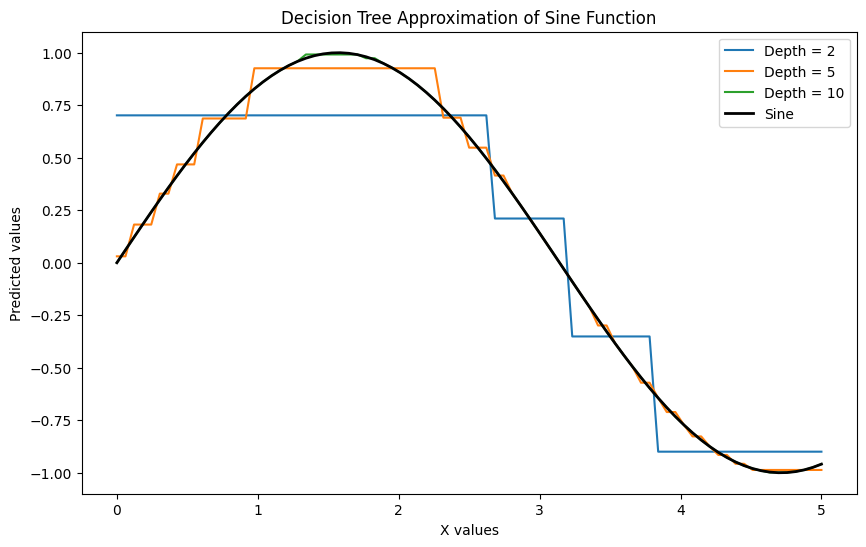

In [12]:
depth_values = [2, 5, 10]

plt.figure(figsize=(10, 6))

for depth in depth_values:
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(X, y)
    y_pred = model.predict(X)
    plt.plot(X, y_pred, label=f"Depth = {depth}")

plt.plot(X, y, label="Sine", color='black', linewidth=2)

plt.title('Decision Tree Approximation of Sine Function')
plt.xlabel('X values')
plt.ylabel('Predicted values')
plt.legend()

plt.show()

`We now define a new test set, with values out of the training set.
Try the Decision Tree regressor on this new test set.
Plot the obtained results.`

In [13]:
X_test_new = np.arange(0.0, 10.0, 0.1)[:, np.newaxis]
y_test_new = np.sin(X_test_new).ravel()

`Can you explain this phenomenon? How does the training of the tree causes it?`

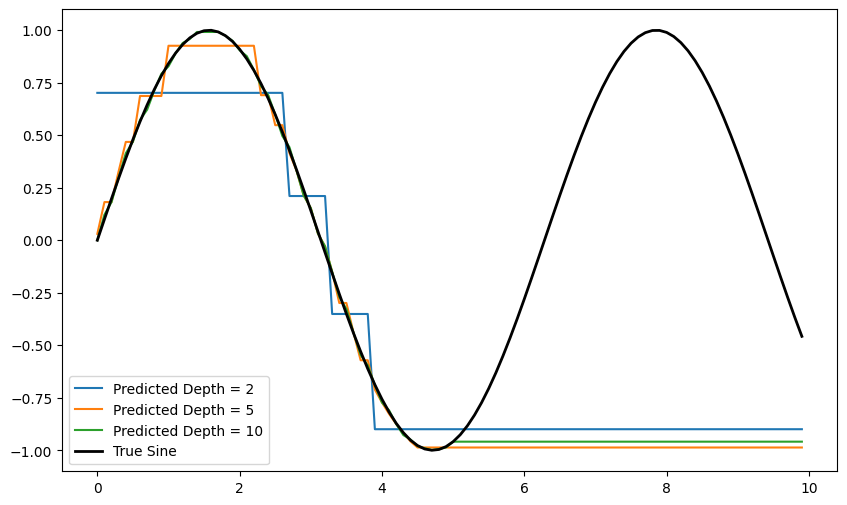

In [13]:

plt.figure(figsize=(10, 6))

for depth in depth_values:
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(X, y)
    
    y_test_pred = model.predict(X_test_new)
    plt.plot(X_test_new, y_test_pred, label=f"Predicted Depth = {depth}")

plt.plot(X_test_new, y_test_new, label="True Sine", color='black', linewidth=2)

plt.legend()

plt.show()


`What other model you know could overcome this situation?`

In [ ]:
##maybe use CV or heavy boosting

## Model explaining- LIMING things up
```We will try to explain complicated models using Decision Trees, and will get to know some concepts in the field.```

```We will use the MNIST data set.```

In [14]:
df = pd.read_csv('c:/Users/user/Desktop/DStrainig/intro/supervised/MNIST_train.csv')
target = df['label']
df = df.drop('label', axis = 1)
df_train, df_test, target_train, target_test = train_test_split(df, target, train_size = 0.7, test_size = 0.3)

```Train a LGBMClassifier on the data set, using max_depth=10, n_estimators=250 (and, of course, n_jobs = -1). How good is your model?```

In [17]:
from lightgbm import LGBMClassifier
lgb = LGBMClassifier(max_depth=10, n_estimators=250, n_jobs=-1)
lgb.fit(df_train, target_train)
print(accuracy_score(target_train, lgb.predict(df_train)))
print(accuracy_score(target_test, lgb.predict(df_test)))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.105901 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 101022
[LightGBM] [Info] Number of data points in the train set: 29399, number of used features: 610
[LightGBM] [Info] Start training from score -2.320743
[LightGBM] [Info] Start training from score -2.187948
[LightGBM] [Info] Start training from score -2.305958
[LightGBM] [Info] Start training from score -2.260913
[LightGBM] [Info] Start training from score -2.337509
[LightGBM] [Info] Start training from score -2.399632
[LightGBM] [Info] Start training from score -2.322823
[LightGBM] [Info] Start training from score -2.255706
[LightGBM] [Info] Start training from score -2.350627
[LightGBM] [Info] Start training from score -2.299495
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warnin

```Read The short paper Model-Agnostic Interpretability of Machine Learning by Riberio et al, which you can find in the papers directory. We are about to try to make the LIME method proposed in the paper work, using Decision Tree. We would like to train a simple and interpretable model that predicts, locally, the predictions of our LGBMClassifier.
Create the targets (train and test) for the interpretable model, as described in the paper.```

In [18]:
target_train = lgb.predict(df_train)
target_test = lgb.predict(df_test)

```Create a function that gets a sample and returns a weight function. The weight function will get a sample (or multiple samples) and return the each sample's weight, using the following function: ``` y_weight $ = \frac{1}{|x-y|+1}$

```where x is the original sample and y is the sample that we would like to get its weight.
Note: we are about to use this function in order to define the "neighborhood" of a point - this definition is crucial in LIME.```

In [21]:
def get_weights(sample):
    def metric(x):
        if len(np.array(x).shape) > 1:
            y = np.linalg.norm(np.array(sample) - np.array(x), axis = 1)
        else:
            y = np.linalg.norm(np.array(sample) - np.array(x))
        return 1/(y+1)
    return metric

```Make sure your function is good: pick a sample and print the images of the 20 most weighted samples in the data set, compared to the sample you picked.```

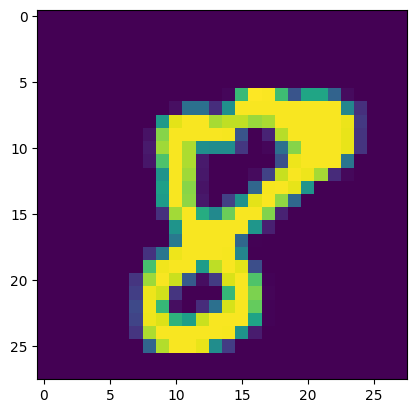

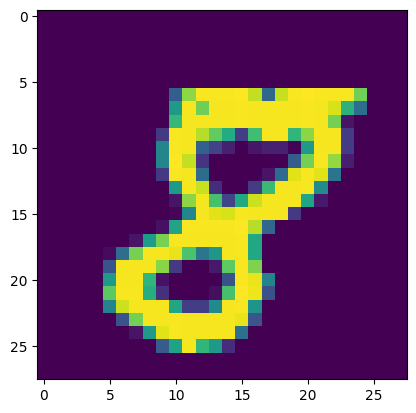

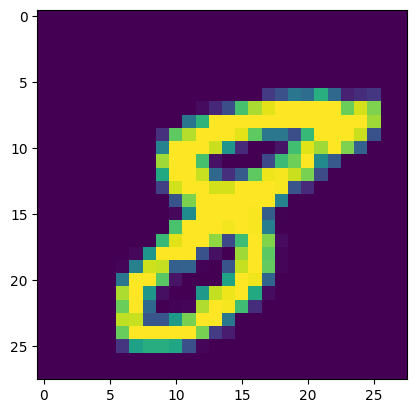

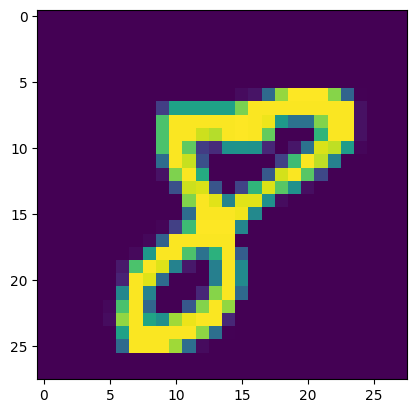

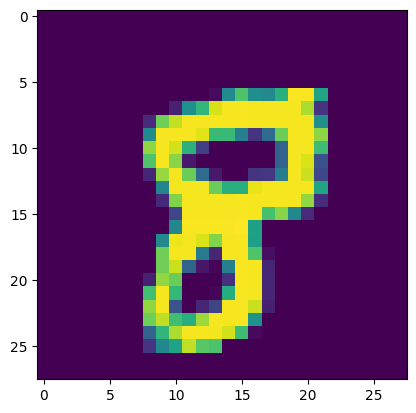

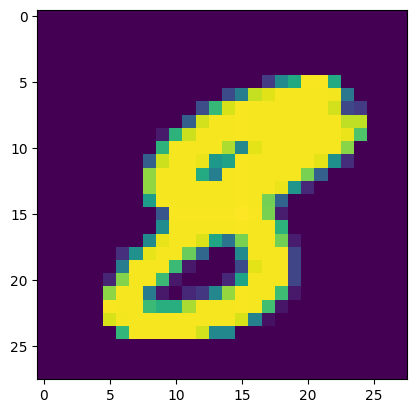

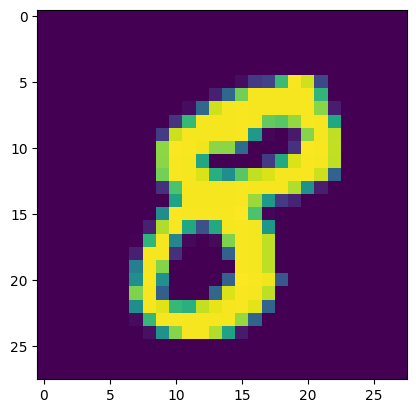

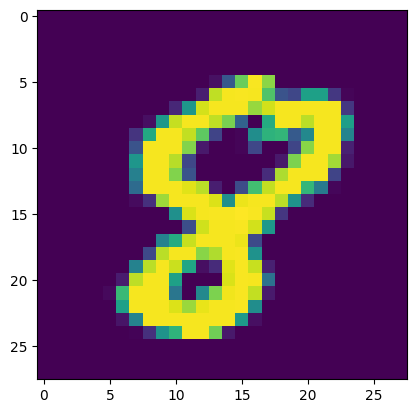

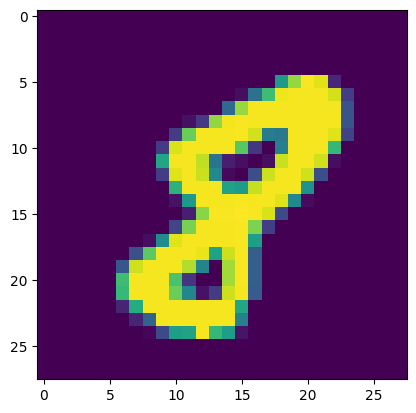

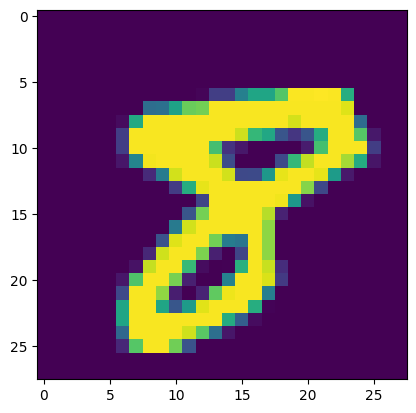

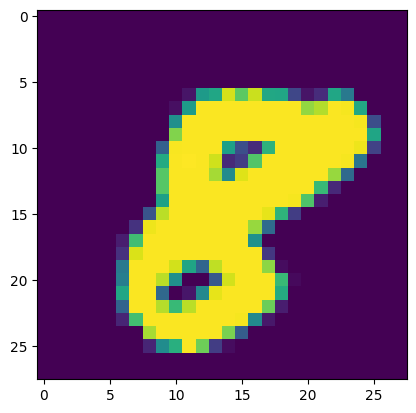

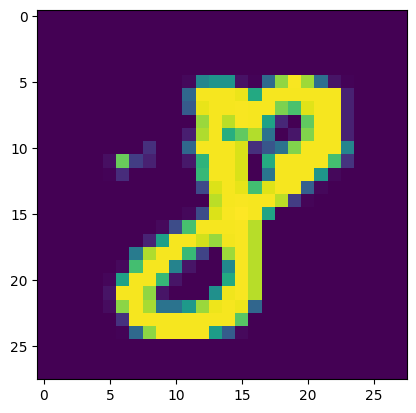

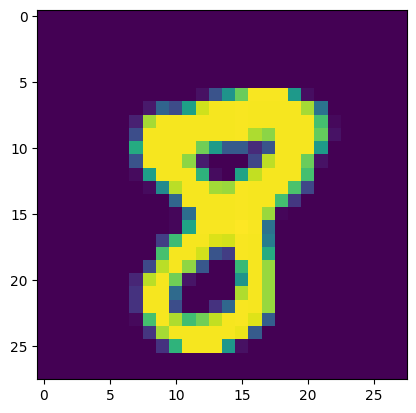

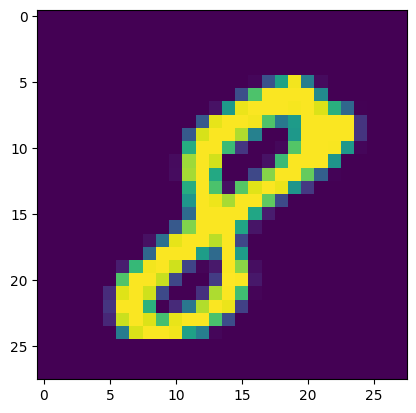

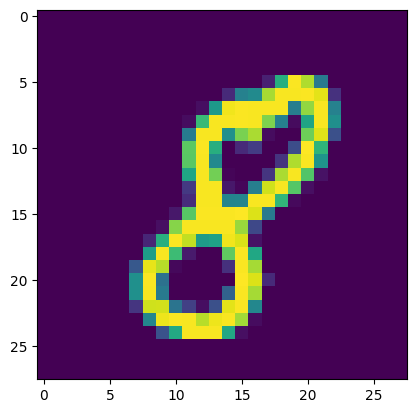

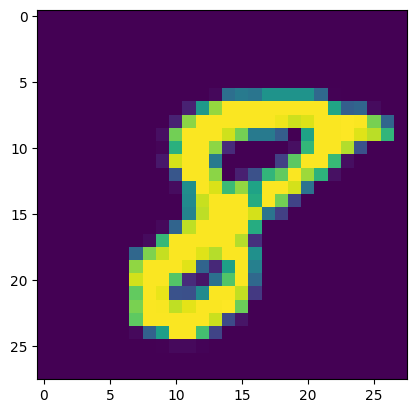

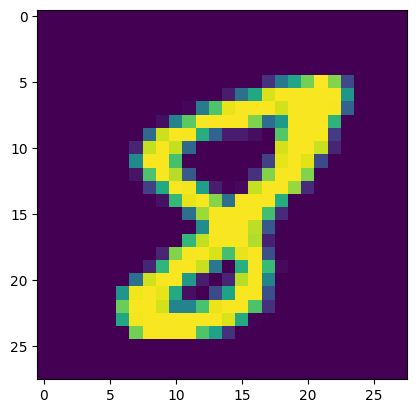

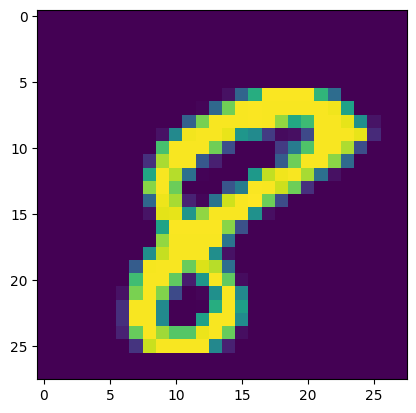

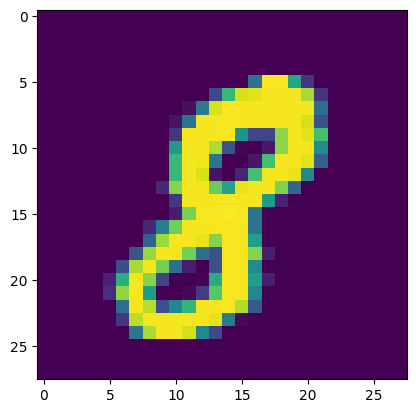

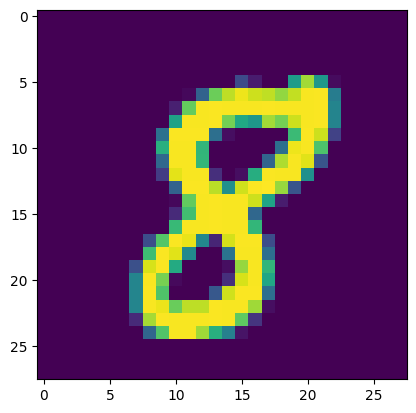

In [22]:
distance = get_weights(df.iloc[10])
weights = distance(df_train.values)
for i in map(lambda x: x[0], sorted(zip(range(len(weights)), weights), key = lambda x: -x[1])[:20]):
    plt.imshow(df_train.iloc[i].values.reshape((28,28)))
    plt.show()

```for every digit, do the following:```
- ```take a sample of it from the dataset.```
- ```Our interpretable model is going to be a decision tree with max_depth = 5. Create the model.```
- ```Train it using the weights derived from the sample picked and the predictions of the complex LGBMClassifier model.```
- ```Create an empty image, and paint it by the feature_importance of each pixel, which you can get from the interpretable model.```
- ```Paint the image. Can you learn something from the image?```

0.6615641145265856
0.6314309670289476


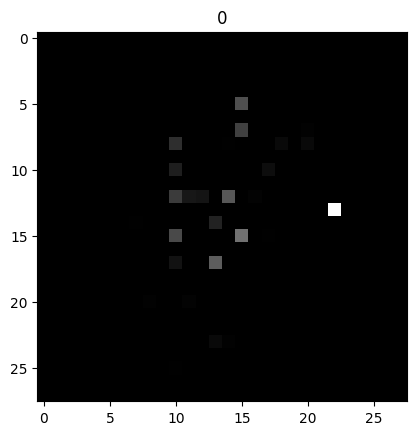

0.6953030960614323
0.6781648464645638


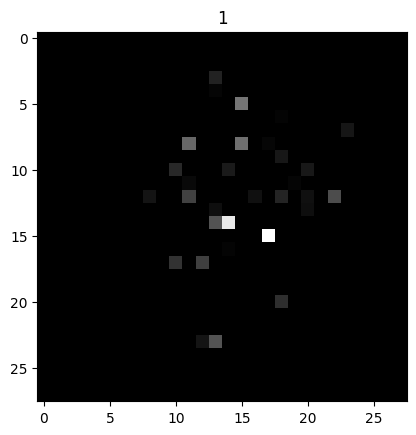

0.6443180585162717
0.6139046076076587


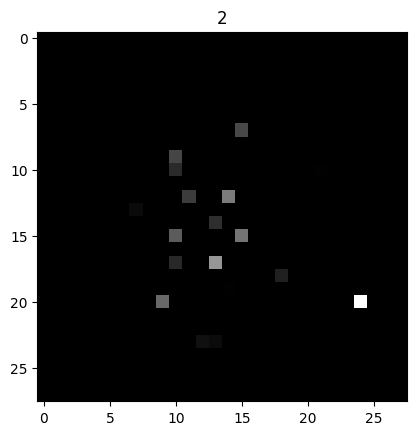

0.626752855780437
0.597911733369961


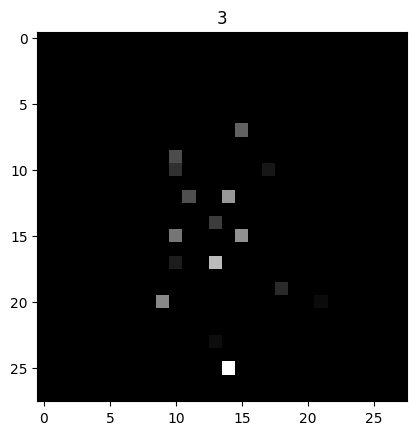

0.6320992588760401
0.602807638001103


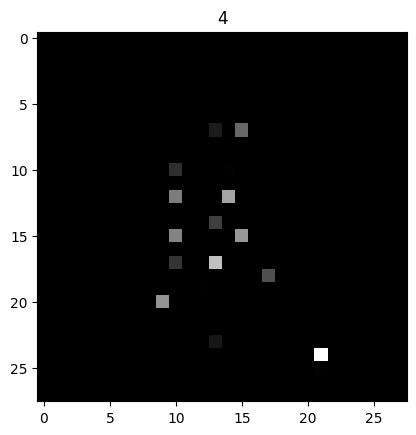

0.6603430261061841
0.6362828701497327


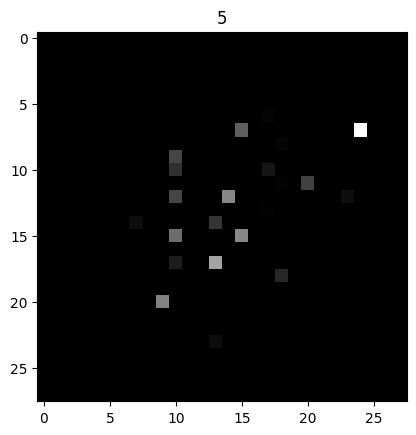

0.6661534117205673
0.6384805372134391


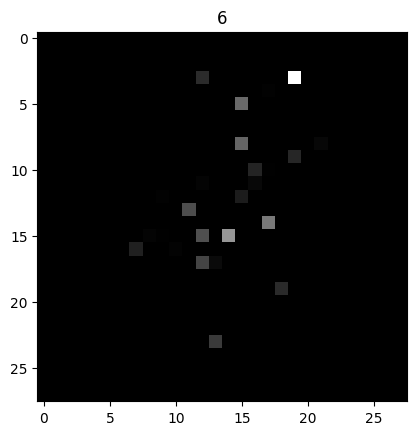

0.6961411739687964
0.7460133745444651


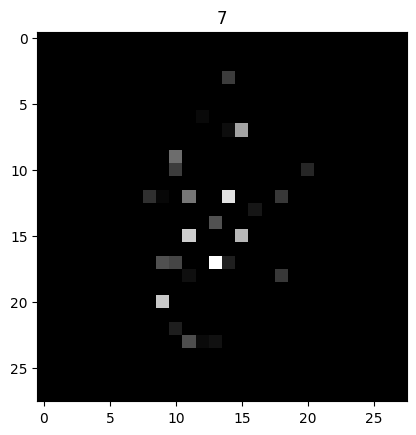

0.6892779224408515
0.7459209345368204


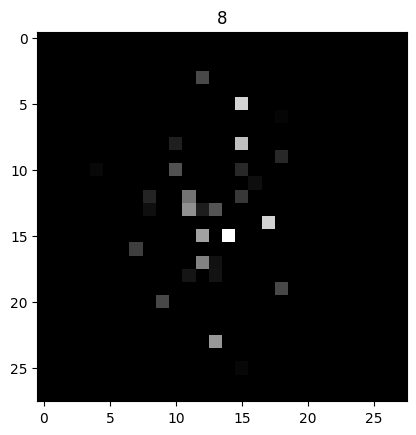

0.6380160385104581
0.6078524387034175


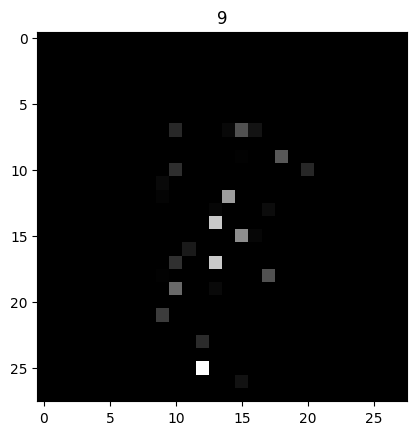

In [25]:
for digit in range(10):
    bitmap = np.zeros((28,28))
    for num in list(target[target==digit].index[:1]):
        distance = get_weights(df.iloc[num])
        weights_train = distance(df_train.values)
        weights_test = distance(df_test.values)

        basic_tree = DecisionTreeClassifier(max_depth=5)
        basic_tree.fit(df_train, target_train, sample_weight=weights_train)
        bitmap = bitmap+basic_tree.feature_importances_.reshape(28,28)
        print(accuracy_score(target_train, basic_tree.predict(df_train), sample_weight = weights_train))
        print(accuracy_score(target_test, basic_tree.predict(df_test), sample_weight = weights_test))
    plt.imshow(bitmap, cmap = 'gray')
    plt.title(digit)
    plt.show()

```What are the biggest problems in LIME? What makes it limited? Regard, in your answer, the way the concept of "locality" is defined.```

In [ ]:
#The main challenge is the fact that the definition of "locality" 
#  does not necessarily reflect the true complexity of the model 
# in the relevant region.

```The field of interpreting models might be very important, especially when working with complex models or with unsupervised learning. This part was a small taste of it, and you are encouraged to ``` **deepen** ``` (see what I did here? :) ) your knowledge about it.```